
# Homework 2
by Anthony Leouie A. Palmera

## Preparing the dataset
Use only the following columns:

- `engine_displacement`
- `horsepower`
- `vehicle_weight`
- `model_year`
- `fuel_efficiency_mpg`

In [2]:
import pandas as pd
import seaborn as sns

In [8]:
data = pd.read_csv('data/car_fuel_efficiency_2026.csv', 
                   usecols=[
                       'engine_displacement',
                       'horsepower',
                       'vehicle_weight',
                       'model_year',
                       'fuel_efficiency_mpg'
                   ])
data

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0
...,...,...,...,...,...
9995,2005,2470,271.0,4690,27.4
9996,1993,2300,244.0,4370,30.0
9997,2014,2480,267.0,4590,28.1
9998,2004,2180,270.0,4450,32.2


## EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

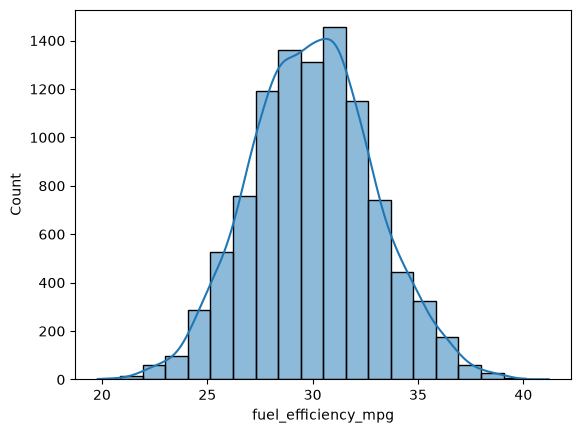

In [12]:
sns.histplot(data['fuel_efficiency_mpg'], bins=20, kde=True)

Answer: <b> It doesn't have a long tail

## Question 1
There's one column with missing values. What is it?

- `engine_displacement`
- `horsepower`
- `vehicle_weight`
- `model_year`

In [13]:
data.isna().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

Answer: <b> `horsepower`

## Question 2
What's the median (50% percentile) for variable `horsepower`?

- 204
- 254
- 304
- 354

In [ ]:
data['horsepower'].median().astype(int)

np.int64(254)

Answer: <b> The median is 254

## Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture:
``` Terminal
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

In [18]:
import numpy as np

# get the length of the dataset
num = len(data)

# calculate the split size
num_val = int(num * 0.2)
num_test = int(num * 0.2)
num_train = num - num_val - num_test

# create index array then shuffle it
index = np.arange(num)
np.random.seed(42) # setting seed 
np.random.shuffle(index)

# data splitting
data_train = data.iloc[index[:num_train]]
data_val = data.iloc[index[num_train:num_train + num_val]]
data_test = data.iloc[index[num_train + num_val:]]

# reset index for each dataset
data_train = data_train.reset_index(drop=True)
data_val = data_val.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)

# get target variables
y_train = data_train['fuel_efficiency_mpg'].values
y_val = data_val['fuel_efficiency_mpg'].values
y_test = data_test['fuel_efficiency_mpg'].values

## Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

Options:
- With 0
- With mean
- Both are equally good

In [19]:
# root mean squared error function
def rmse(y, y_pred): 
    error = (y - y_pred) ** 2
    mse = error.mean()

    return np.sqrt(mse)

# linear regression model
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# prepare the feature matrix
def prepare_X(data):
    X = data[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
    return X

In [27]:
# Option 1. fill missing values with 0
data_train_zero = data_train.copy()
data_val_zero = data_val.copy()

data_train_zero['horsepower'] = data_train_zero['horsepower'].fillna(0)
data_val_zero['horsepower'] = data_val_zero['horsepower'].fillna(0)

In [28]:
# Option 2. fill missing values with median
mean_horsepower = data_train['horsepower'].median()

data_train_median = data_train.copy()
data_val_median = data_val.copy()

data_train_median['horsepower'] = data_train_median['horsepower'].fillna(mean_horsepower)
data_val_median['horsepower'] = data_val_median['horsepower'].fillna(mean_horsepower)

In [31]:
# Train and evaluate the model with zero-filled data
X_train_zero = prepare_X(data_train_zero)
w0_zero, w_zero = linear_regression(X_train_zero, y_train)

X_val_zero = prepare_X(data_val_zero)
y_pred_val_zero = w0_zero + X_val_zero.dot(w_zero)
rmse_zero = round(np.sqrt(rmse(y_val, y_pred_val_zero)), 2)

In [32]:
# Train and evaluate the model with mean-filled data
X_train_median = prepare_X(data_train_median)
w0_median, w_median = linear_regression(X_train_median, y_train)

X_val_median = prepare_X(data_val_median)
y_pred_val_median = w0_median + X_val_median.dot(w_median)
rmse_median = round(np.sqrt(rmse(y_val, y_pred_val_median)), 2)

In [33]:
print(f'RMSE with zero-filled data: {rmse_zero}')
print(f'RMSE with mean-filled data: {rmse_median}')

RMSE with zero-filled data: 1.49
RMSE with mean-filled data: 1.48


Answer: Since, lower RMSE is always better. Therefore, <b> with Mean

## Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which `r` gives the best RMSE?
- If multiple options give the same best RMSE, select the smallest `r`.

Options:
- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [35]:
# regularized linear regression model
def train_linear_regression(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX += r * np.eye(XTX.shape[0])  # regularization term

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [37]:
# prepare missing values with zero-filled data
data_train_zero = data_train.copy()
data_val_zero = data_val.copy()

data_train_zero['horsepower'] = data_train_zero['horsepower'].fillna(0)
data_val_zero['horsepower'] = data_val_zero['horsepower'].fillna(0)


In [38]:
# features
X_train = prepare_X(data_train_zero)
X_val = prepare_X(data_val_zero)

In [42]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    # model training
    w0, w = train_linear_regression(X_train, y_train, r=r)

    # model prediction
    y_pred = w0 + X_val.dot(w)

    # calculate RMSE
    rmse_score = np.sqrt(rmse(y_val, y_pred))
    rmse_scores[r] = rmse_score
    print(f'r={r}: RMSE={rmse_score}')

r=0: RMSE=1.4850229610189232
r=0.01: RMSE=1.485202887376673
r=0.1: RMSE=1.4913561874297654
r=1: RMSE=1.532719442165733
r=5: RMSE=1.5522178218921305
r=10: RMSE=1.5554645175873505
r=100: RMSE=1.558589791451324


In [44]:
best_score = float('inf')
best_r = None

for r in r_values:
    current_score = rmse_scores[r]
    
    if current_score < best_score:
        best_score = current_score
        best_r = r

print(f"\nBest r value: {best_r} (RMSE = {best_score})")


Best r value: 0 (RMSE = 1.4850229610189232)


Answer: <b> The smallest r value is 0

##  Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
- Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?
- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is <i>stable.

In [45]:
# Calculate RMSE for a given seed
def calculate_rmse_for_seed(seed, data):
    # data splitting
    n = len(data)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    # create index array then shuffle it
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    # split into train/val
    data_train = data.iloc[idx[:n_train]].reset_index(drop=True)
    data_val = data.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    # fill missing values with zero
    data_train_zero = data_train.copy()
    data_val_zero = data_val.copy()
    data_train_zero['horsepower'] = data_train_zero['horsepower'].fillna(0)
    data_val_zero['horsepower'] = data_val_zero['horsepower'].fillna(0)

    # prepare features
    X_train = prepare_X(data_train_zero)
    X_val = prepare_X(data_val_zero)
    y_train = data_train_zero['fuel_efficiency_mpg'].values
    y_val = data_val_zero['fuel_efficiency_mpg'].values

    # train model
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    # calculate RMSE
    return np.sqrt(rmse(y_val, y_pred))

In [47]:
# Calculate RMSE for different seeds
seeds = list(range(10))

rmse_results = []

for seed in seeds:
    rmse_score = calculate_rmse_for_seed(seed, data)
    rmse_results.append(rmse_score)
    print(f'Seed {seed}, RMSE: {rmse_score:.3f}')

Seed 0, RMSE: 1.496
Seed 1, RMSE: 1.484
Seed 2, RMSE: 1.471
Seed 3, RMSE: 1.485
Seed 4, RMSE: 1.484
Seed 5, RMSE: 1.499
Seed 6, RMSE: 1.507
Seed 7, RMSE: 1.480
Seed 8, RMSE: 1.489
Seed 9, RMSE: 1.486


In [49]:
# calculate standard deviation of RMSE results
std_rmse = round(np.std(rmse_results), 3)
print(f'Standard Deviation of RMSE: {std_rmse:.3f}')

# calculate mean of RMSE results
mean_rmse = round(np.mean(rmse_results), 3)
print(f'Mean of RMSE: {mean_rmse:.3f}')

Standard Deviation of RMSE: 0.010
Mean of RMSE: 1.488


Model is <i>stable</i> \
0.010 ≈ 0.006 \
Answer: <b> 0.006

## Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

Options:
- 0.236
- 2.236
- 22.10
- 221.0

In [50]:
# get the length of the dataset
n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# create index array then shuffle it
index = np.arange(n)
np.random.seed(9) # as required
np.random.shuffle(index)

# data splitting
data_train = data.iloc[index[:n_train]]
data_val = data.iloc[index[n_train:n_train + n_val]]
data_test = data.iloc[index[n_train + n_val:]]

# combine train and validation sets
data_train_val = pd.concat([data_train, data_val]).reset_index(drop=True)

# fill missing values with zero
data_train_val['horsepower'] = data_train_val['horsepower'].fillna(0)
data_test['horsepower'] = data_test['horsepower'].fillna(0)

# prepare features
X_train_val = prepare_X(data_train_val)
X_test = prepare_X(data_test)

# prepare target variables
y_train_val = data_train_val['fuel_efficiency_mpg'].values
y_test = data_test['fuel_efficiency_mpg'].values

# train model 
w0, w = train_linear_regression(X_train_val, y_train_val, r=0.001) # as required

# make predictions
y_pred = w0 + X_test.dot(w)

# calculate RMSE
final_rmse = rmse(y_test, y_pred)
print(f'Final RMSE on test set: {final_rmse:.3f}')


Final RMSE on test set: 2.236


Answer: <b> 2.236